In [ ]:
# Copyright (c) 2026 Rioborue Alexander Oghenerume. All rights reserved.
# This code cannot be used, modified, or distributed without permission.
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Seminar.xlsx to Seminar.xlsx


In [ ]:
df = pd.read_excel("Seminar.xlsx")

In [ ]:
y = df['AA']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df[['TA', 'AI']], y,
    test_size=0.20,
    random_state=42
)

In [ ]:
def evaluate_model(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    print(f"\n{name}")
    print(f"R²   : {r2:.3f}")
    print(f"RMSE : {rmse:.3f}")
    print(f"MAE  : {mae:.3f}")

    return r2, rmse, mae

In [ ]:
enet_params = {
    'enet__alpha': [0.01, 0.1, 1.0],
    'enet__l1_ratio': [0.3, 0.5, 0.7]
}

rf_params = {
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

In [ ]:
enet_ta = GridSearchCV(
    Pipeline([
        ('scaler', StandardScaler()),
        ('enet', ElasticNet(max_iter=10000, random_state=42))
    ]),
    enet_params,
    cv=10,
    scoring='r2'
)

enet_ta.fit(X_train[['TA']], y_train)
pred_enet_ta = enet_ta.predict(X_test[['TA']])

evaluate_model("Elastic Net (TA)", y_test, pred_enet_ta)


Elastic Net (TA)
R²   : 0.206
RMSE : 9.328
MAE  : 7.650


(0.20641983091128902, np.float64(9.327973740576775), 7.649511651650433)

In [ ]:
enet_ai = GridSearchCV(
    Pipeline([
        ('scaler', StandardScaler()),
        ('enet', ElasticNet(max_iter=10000, random_state=42))
    ]),
    enet_params,
    cv=10,
    scoring='r2'
)

enet_ai.fit(X_train[['AI']], y_train)
pred_enet_ai = enet_ai.predict(X_test[['AI']])

evaluate_model("Elastic Net (AI)", y_test, pred_enet_ai)


Elastic Net (AI)
R²   : 0.269
RMSE : 8.954
MAE  : 7.177


(0.26873004826374114, np.float64(8.954282166577586), 7.177041477393455)

In [ ]:
enet_both = GridSearchCV(
    Pipeline([
        ('scaler', StandardScaler()),
        ('enet', ElasticNet(max_iter=10000, random_state=42))
    ]),
    enet_params,
    cv=10,
    scoring='r2'
)

enet_both.fit(X_train[['TA', 'AI']], y_train)
pred_enet_both = enet_both.predict(X_test[['TA', 'AI']])

evaluate_model("Elastic Net (TA + AI)", y_test, pred_enet_both)


Elastic Net (TA + AI)
R²   : 0.488
RMSE : 7.494
MAE  : 6.069


(0.48774017613490817, np.float64(7.494403285192956), 6.068855021567551)

In [ ]:
coef = enet_both.best_estimator_.named_steps['enet'].coef_
print("\nElastic Net coefficients:")
print(f"Test Anxiety (TA): {coef[0]:.3f}")
print(f"Academic Interest (AI): {coef[1]:.3f}")


Elastic Net coefficients:
Test Anxiety (TA): -4.965
Academic Interest (AI): 5.502


In [ ]:
rf_ta = GridSearchCV(
    RandomForestRegressor(
        n_estimators=500,
        random_state=42
    ),
    rf_params,
    cv=10,
    scoring='r2'
)

rf_ta.fit(X_train[['TA']], y_train)
pred_rf_ta = rf_ta.predict(X_test[['TA']])

evaluate_model("Random Forest (TA)", y_test, pred_rf_ta)


Random Forest (TA)
R²   : 0.258
RMSE : 9.021
MAE  : 7.297


(0.25784395286607253, np.float64(9.020685189184688), 7.296707226146779)

In [ ]:
rf_ai = GridSearchCV(
    RandomForestRegressor(
        n_estimators=500,
        random_state=42
    ),
    rf_params,
    cv=10,
    scoring='r2'
)

rf_ai.fit(X_train[['AI']], y_train)
pred_rf_ai = rf_ai.predict(X_test[['AI']])

evaluate_model("Random Forest (AI)", y_test, pred_rf_ai)


Random Forest (AI)
R²   : 0.285
RMSE : 8.851
MAE  : 7.070


(0.2854630341761971, np.float64(8.85124296572467), 7.070154901887532)

In [ ]:
rf_both = GridSearchCV(
    RandomForestRegressor(
        n_estimators=500,
        random_state=42
    ),
    rf_params,
    cv=10,
    scoring='r2'
)

rf_both.fit(X_train[['TA', 'AI']], y_train)
pred_rf_both = rf_both.predict(X_test[['TA', 'AI']])

evaluate_model("Random Forest (TA + AI)", y_test, pred_rf_both)


Random Forest (TA + AI)
R²   : 0.481
RMSE : 7.545
MAE  : 6.180


(0.4807434271341978, np.float64(7.545411207975344), 6.179769119028434)

In [ ]:
results = pd.DataFrame([
    ["ENET (TA)", *evaluate_model("ENET (TA)", y_test, pred_enet_ta)],
    ["ENET (AI)", *evaluate_model("ENET (AI)", y_test, pred_enet_ai)],
    ["ENET (TA + AI)", *evaluate_model("ENET (TA + AI)", y_test, pred_enet_both)],
    ["RF (TA)", *evaluate_model("RF (TA)", y_test, pred_rf_ta)],
    ["RF (AI)", *evaluate_model("RF (AI)", y_test, pred_rf_ai)],
    ["RF (TA + AI)", *evaluate_model("RF (TA + AI)", y_test, pred_rf_both)],
], columns=["Model", "R²", "RMSE", "MAE"])

results


ENET (TA)
R²   : 0.206
RMSE : 9.328
MAE  : 7.650

ENET (AI)
R²   : 0.269
RMSE : 8.954
MAE  : 7.177

ENET (TA + AI)
R²   : 0.488
RMSE : 7.494
MAE  : 6.069

RF (TA)
R²   : 0.258
RMSE : 9.021
MAE  : 7.297

RF (AI)
R²   : 0.285
RMSE : 8.851
MAE  : 7.070

RF (TA + AI)
R²   : 0.481
RMSE : 7.545
MAE  : 6.180


,Model,R²,RMSE,MAE
0,ENET (TA),0.206420,9.327974,7.649512
1,ENET (AI),0.268730,8.954282,7.177041
2,ENET (TA + AI),0.487740,7.494403,6.068855
3,RF (TA),0.257844,9.020685,7.296707
4,RF (AI),0.285463,8.851243,7.070155
5,RF (TA + AI),0.480743,7.545411,6.179769


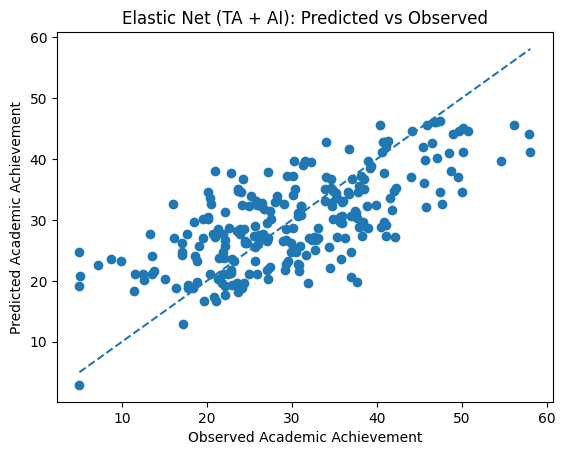

In [ ]:
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(y_test, pred_enet_both)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)
plt.xlabel("Observed Academic Achievement")
plt.ylabel("Predicted Academic Achievement")
plt.title("Elastic Net (TA + AI): Predicted vs Observed")
plt.show()

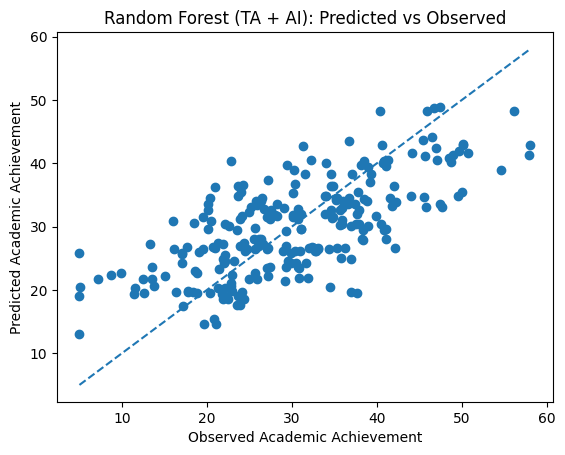

In [ ]:
plt.figure()
plt.scatter(y_test, pred_rf_both)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)
plt.xlabel("Observed Academic Achievement")
plt.ylabel("Predicted Academic Achievement")
plt.title("Random Forest (TA + AI): Predicted vs Observed")
plt.show()

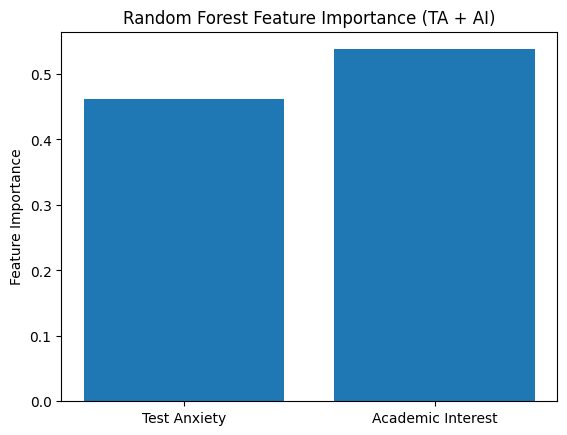

In [ ]:
importances = rf_both.best_estimator_.feature_importances_
plt.figure()
plt.bar(['Test Anxiety', 'Academic Interest'], importances)
plt.ylabel("Feature Importance")
plt.title("Random Forest Feature Importance (TA + AI)")
plt.show()

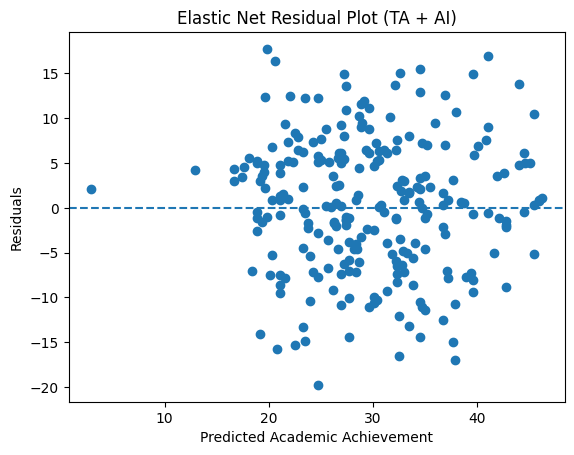

In [ ]:
residuals = y_test - pred_enet_both
plt.figure()
plt.scatter(pred_enet_both, residuals)
plt.axhline(0, linestyle='--')
plt.xlabel("Predicted Academic Achievement")
plt.ylabel("Residuals")
plt.title("Elastic Net Residual Plot (TA + AI)")
plt.show()